In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
df = pd.read_csv("C:/CourseWork/Dissertation Classifying grip strategies using machine learning/data/02_processed/prehension_master_dataset.csv")
df.head(3)

,subjName,trialN,visCond,surface,distance,DOB,Gender,Dominant.Eye,clear.logMAR,mono.logMAR,...,timeToXmax_thumb,timeToXmax_wrist,timeToYmax_index,timeToYmax_knuck,timeToYmax_thumb,timeToYmax_wrist,timeToZmax_index,timeToZmax_knuck,timeToZmax_thumb,timeToZmax_wrist
0,1,1,clear,black,near,13/05/2003,Male,Right,-0.02,-0.04,...,3.308333,3.316667,2.691667,3.125,2.675000,2.758333,2.950000,2.966667,3.241667,2.983333
1,1,2,clear,black,far,13/05/2003,Male,Right,-0.02,-0.04,...,3.775000,4.050000,2.991667,3.500,2.941667,3.500000,3.608333,3.675000,3.625000,3.666667
2,1,3,clear,wood,middle,13/05/2003,Male,Right,-0.02,-0.04,...,3.666667,3.691667,2.908333,3.475,2.891667,3.483333,3.300000,3.325000,3.291667,3.325000


In [ ]:
# Feature Selection
# Define columns by their roles based on the new structure
identifier_cols = ['subjName', 'trialN', 'DOB', 'Gender', 'Dominant.Eye']
condition_cols = ['visCond', 'surface', 'distance']
# All other numeric columns are potential kinematic/vision features
kinematic_features = df.select_dtypes(include=np.number).columns.tolist()
# Remove identifier columns from the feature list
kinematic_features = [col for col in kinematic_features if col not in ['subjName', 'trialN']]

print(f"\nIdentified {len(kinematic_features)} kinematic and vision features for modeling.")


Identified 173 kinematic and vision features for modeling.


In [ ]:
# Handle Categorical Data (for supervised target) & Prepare Data
X = df[kinematic_features].copy()
y_supervised = df['distance']
groups = df['subjName']

# Check for and handle any potential missing values
if X.isnull().sum().sum() > 0:
    print("\nWarning: Missing values detected. Filling with the column mean.")
    X = X.fillna(X.mean())

In [ ]:
#  Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\nFeatures have been scaled using StandardScaler.")


Features have been scaled using StandardScaler.


#  Phase 1: Unsupervised Learning Discovering Grip Strategies

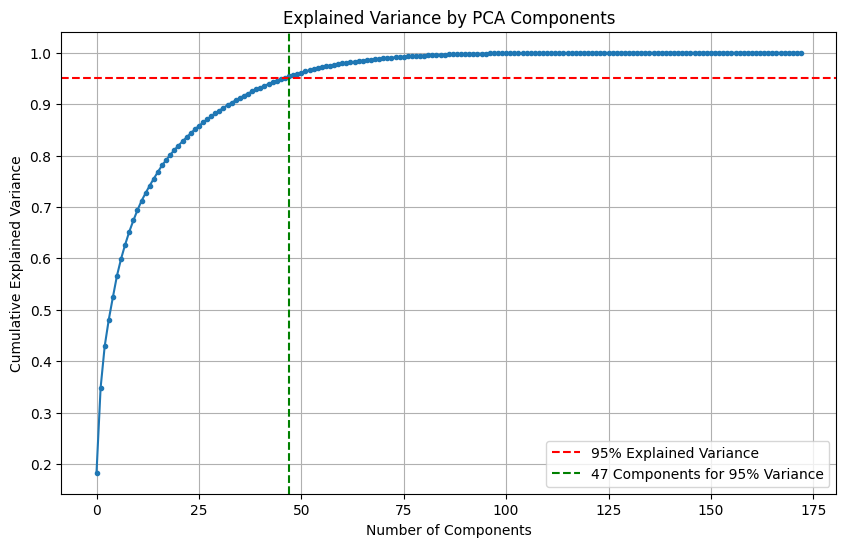


Number of components to explain 95% of variance: 47
Data transformed using PCA into 47 components.


In [ ]:
# Dimensionality Reduction (PCA)
# Determine the number of components to explain 95% of the variance
pca_test = PCA()
pca_test.fit(X_scaled)
n_components_95 = np.where(np.cumsum(pca_test.explained_variance_ratio_) >= 0.95)[0][0] + 1

# Plot the explained variance
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca_test.explained_variance_ratio_), marker='.', linestyle='-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Explained Variance')
plt.axvline(x=n_components_95, color='g', linestyle='--', label=f'{n_components_95} Components for 95% Variance')
plt.legend()
plt.show()

print(f"\nNumber of components to explain 95% of variance: {n_components_95}")

# Apply PCA with the chosen number of components
pca = PCA(n_components=n_components_95)
X_pca = pca.fit_transform(X_scaled)
print(f"Data transformed using PCA into {X_pca.shape[1]} components.")


# Cluster Analysis

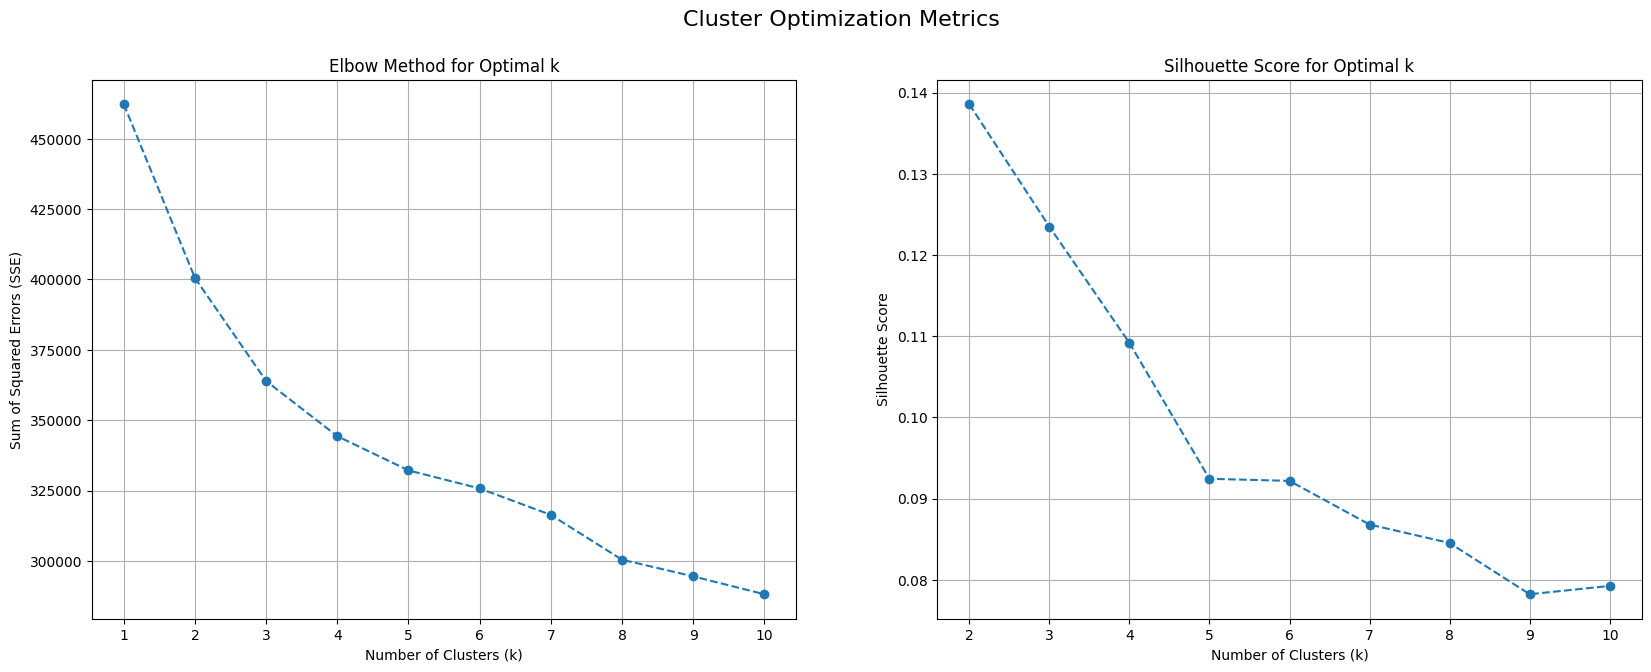

In [7]:
# Calculate SSE (for Elbow) and Silhouette Scores
sse = []
silhouette_scores = []
# Note: Silhouette score requires at least 2 clusters.
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_pca)
    sse.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, kmeans.labels_))

# Plot Elbow and Silhouette Score side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

# Elbow Method Plot
# We use range(1,11) for plotting, so we need to calculate k=1 for SSE
sse_plot = [KMeans(n_clusters=1, random_state=42, n_init='auto').fit(X_pca).inertia_] + sse
ax1.plot(range(1, 11), sse_plot, marker='o', linestyle='--')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Sum of Squared Errors (SSE)')
ax1.set_title('Elbow Method for Optimal k')
ax1.set_xticks(range(1, 11))
ax1.grid(True)

# Silhouette Score Plot
ax2.plot(k_range, silhouette_scores, marker='o', linestyle='--')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score for Optimal k')
ax2.set_xticks(k_range)
ax2.grid(True)

plt.suptitle('Cluster Optimization Metrics', fontsize=16)
plt.show()


In [8]:
# Determine optimal k from each method
optimal_k_elbow = 4
# The optimal k for silhouette score is the one that maximizes the score
optimal_k_sil = k_range[np.argmax(silhouette_scores)]

print(f"Optimal k from Elbow Method: {optimal_k_elbow}")
print(f"Optimal k from Silhouette Score: {optimal_k_sil}")

# --- Horizontal Rule ---
print("\n" + "="*80 + "\n")

Optimal k from Elbow Method: 4
Optimal k from Silhouette Score: 2




# Full Analysis for k from Elbow Method (k=4)


In [ ]:
print(f"--- Analysis for k = {optimal_k_elbow} (from Elbow Method) ---\n")

# K-Means and Hierarchical Clustering
kmeans_elbow = KMeans(n_clusters=optimal_k_elbow, random_state=42, n_init='auto')
df['kmeans_strategy_elbow'] = kmeans_elbow.fit_predict(X_pca)

hierarchical_elbow = AgglomerativeClustering(n_clusters=optimal_k_elbow, linkage='ward')
df['hierarchical_strategy_elbow'] = hierarchical_elbow.fit_predict(X_pca)
print(f"Assigned clusters for k={optimal_k_elbow} using both K-Means and Hierarchical methods.")

--- Analysis for k = 4 (from Elbow Method) ---

Assigned clusters for k=4 using both K-Means and Hierarchical methods.


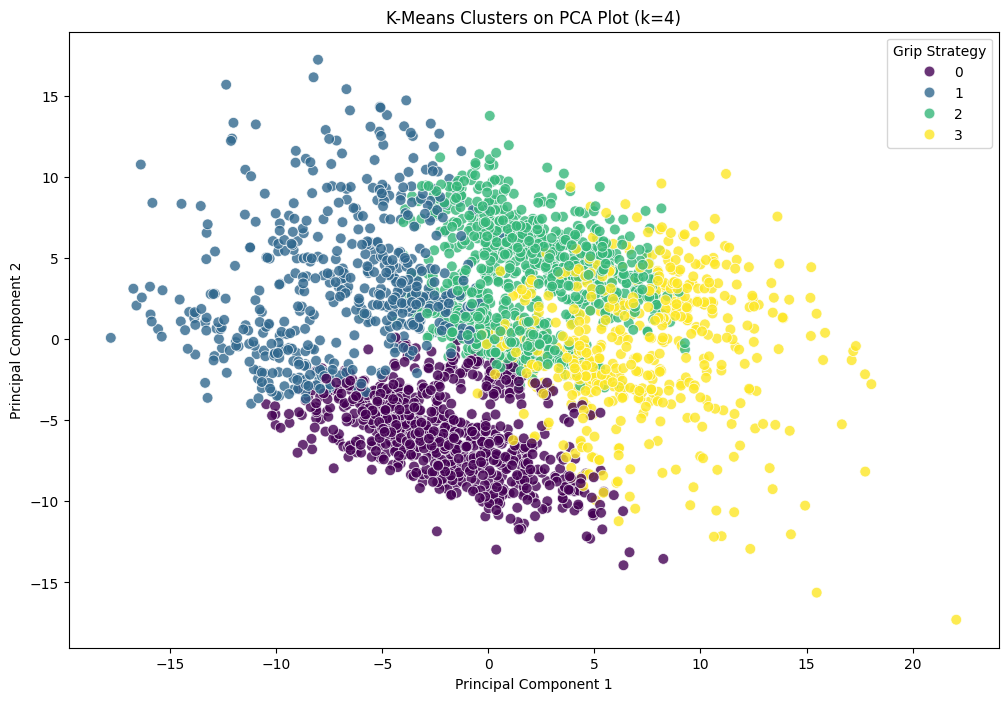

In [ ]:
# Visualization
pca_df_elbow = pd.DataFrame(data=X_pca[:, :2], columns=['PC1', 'PC2'])
pca_df_elbow['grip_strategy'] = df['kmeans_strategy_elbow']

plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='grip_strategy', data=pca_df_elbow, palette='viridis', alpha=0.8, s=60)
plt.title(f'K-Means Clusters on PCA Plot (k={optimal_k_elbow})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Grip Strategy')
plt.show()


In [ ]:
# Interpretation and Comparison
key_features_for_analysis = ['movTime', 'MVel', 'MAcc', 'MGA', 'pathLength', 'clear.logMAR']

print("\n--- Interpretation & Comparison ---\n")
print("Relationship between K-Means strategies and 'distance' condition:")
print(pd.crosstab(df['kmeans_strategy_elbow'], df['distance']))

print("\nMean of key features for each K-Means strategy:")
print(df.groupby('kmeans_strategy_elbow')[key_features_for_analysis].mean().round(3))

print("\nCrosstab comparing K-Means vs. Hierarchical labels:")
print(pd.crosstab(df['kmeans_strategy_elbow'], df['hierarchical_strategy_elbow']))

ari_score_elbow = adjusted_rand_score(df['kmeans_strategy_elbow'], df['hierarchical_strategy_elbow'])
print(f"\nAdjusted Rand Index (ARI): {ari_score_elbow:.4f}")
if ari_score_elbow > 0.75:
    print("Interpretation: High agreement between K-Means and Hierarchical clustering.")
else:
    print("Interpretation: Moderate or low agreement between methods.")


--- Interpretation & Comparison ---

Relationship between K-Means strategies and 'distance' condition:
distance               far  middle  near
kmeans_strategy_elbow                   
0                        2     104   732
1                      102     259   169
2                      591     327     0
3                      243     251    46

Mean of key features for each K-Means strategy:
                       movTime   MVel   MAcc    MGA  pathLength  clear.logMAR
kmeans_strategy_elbow                                                        
0                        3.783  0.856  6.971  0.108       0.973        -0.015
1                        3.576  1.129  9.525  0.110       0.444        -0.075
2                        3.804  1.327  8.869  0.109       0.521        -0.005
3                        4.175  1.285  9.080  0.109       0.492        -0.029

Crosstab comparing K-Means vs. Hierarchical labels:
hierarchical_strategy_elbow    0    1    2    3
kmeans_strategy_elbow           

The low agreement with hierarchical clustering confirms that the boundaries between these four micro-strategies are complex and that K-Means and Hierarchical Clustering disagree on how to draw them.

# Full Analysis for k from Silhouette Score


In [14]:
print(f"--- Analysis for k = {optimal_k_sil} (from Silhouette Score) ---\n")

# 3.1: K-Means and Hierarchical Clustering
kmeans_sil = KMeans(n_clusters=optimal_k_sil, random_state=42, n_init='auto')
df['kmeans_strategy_sil'] = kmeans_sil.fit_predict(X_pca)

hierarchical_sil = AgglomerativeClustering(n_clusters=optimal_k_sil, linkage='ward')
df['hierarchical_strategy_sil'] = hierarchical_sil.fit_predict(X_pca)
print(f"Assigned clusters for k={optimal_k_sil} using both K-Means and Hierarchical methods.")

--- Analysis for k = 2 (from Silhouette Score) ---

Assigned clusters for k=2 using both K-Means and Hierarchical methods.


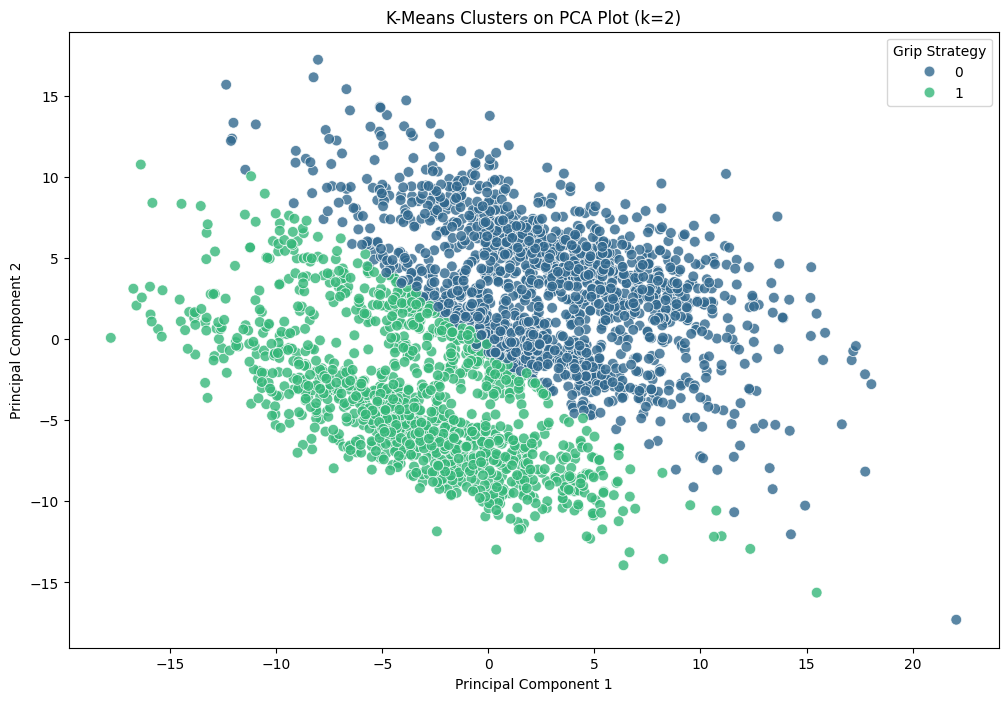

In [15]:
# 3.2: Visualization
pca_df_sil = pd.DataFrame(data=X_pca[:, :2], columns=['PC1', 'PC2'])
pca_df_sil['grip_strategy'] = df['kmeans_strategy_sil']

plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='grip_strategy', data=pca_df_sil, palette='viridis', alpha=0.8, s=60)
plt.title(f'K-Means Clusters on PCA Plot (k={optimal_k_sil})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Grip Strategy')
plt.show()

The plot shows a overlapping division. The green cluster occupies the lower-left portion of the data cloud, while the blue cluster occupies the upper-right. 

Strategy 0: This strategy is used almost exclusively for far (934 trials) and middle (607 trials) distances. It is almost never used for near objects (only 4 trials). Its kinematics show it is the faster (MVel 1.333) and more powerful (MAcc 9.215) of the two strategies.

Strategy 1: This strategy is the clear counterpart, used for near (943 trials) and middle (334 trials) distances, and almost never for far objects (4 trials). Its kinematics show it is slower (MVel 0.911), less powerful (MAcc 7.571), and has a longer, more curved path (pathLength 0.776 vs 0.518).

In [ ]:
# Interpretation and Comparison
print("\n--- Interpretation & Comparison ---\n")
print("Relationship between K-Means strategies and 'distance' condition:")
print(pd.crosstab(df['kmeans_strategy_sil'], df['distance']))

print("\nMean of key features for each K-Means strategy:")
print(df.groupby('kmeans_strategy_sil')[key_features_for_analysis].mean().round(3))

print("\nCrosstab comparing K-Means vs. Hierarchical labels:")
print(pd.crosstab(df['kmeans_strategy_sil'], df['hierarchical_strategy_sil']))

ari_score_sil = adjusted_rand_score(df['kmeans_strategy_sil'], df['hierarchical_strategy_sil'])
print(f"\nAdjusted Rand Index (ARI): {ari_score_sil:.4f}")
if ari_score_sil > 0.75:
    print("Interpretation: High agreement between K-Means and Hierarchical clustering.")
else:
    print("Interpretation: Moderate or low agreement between methods.")



--- Interpretation & Comparison ---

Relationship between K-Means strategies and 'distance' condition:
distance             far  middle  near
kmeans_strategy_sil                   
0                    934     607     4
1                      4     334   943

Mean of key features for each K-Means strategy:
                     movTime   MVel   MAcc    MGA  pathLength  clear.logMAR
kmeans_strategy_sil                                                        
0                      3.901  1.333  9.215  0.110       0.518        -0.018
1                      3.735  0.911  7.571  0.108       0.776        -0.036

Crosstab comparing K-Means vs. Hierarchical labels:
hierarchical_strategy_sil     0    1
kmeans_strategy_sil                 
0                          1492   53
1                           400  881

Adjusted Rand Index (ARI): 0.4609
Interpretation: Moderate or low agreement between methods.


The agreement between K-Means and Hierarchical Clustering is significantly better for the k=2 solution compared to the k=4 solution (0.46 vs 0.29). This means that while they still disagree on some of the "in-between" trials, both algorithms largely agree on what constitutes a "Far-Reach" vs. a "Near-Field" grasp.

# Phase 2: Supervised Learning 

In [ ]:
print("\n Supervised Learning (Predicting 'distance') ---")

# Problem Formulation
# Features (X) are the scaled kinematic/vision features
# Target (y) is the 'distance' condition
le = LabelEncoder()
y_encoded = le.fit_transform(y_supervised)


--- Phase 4: Supervised Learning (Predicting 'distance') ---


In [13]:
pipeline = Pipeline([
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

# Use GroupKFold for subject-aware splitting
group_kfold = GroupKFold(n_splits=5) 

print("\nPerforming 5-fold subject-aware cross-validation...")
# We pass the scaled data (X_scaled) to the pipeline
cv_scores = cross_val_score(pipeline, X_scaled, y_encoded, cv=group_kfold, groups=groups)

print(f"\nCross-validation accuracy scores: {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")



Performing 5-fold subject-aware cross-validation...

Cross-validation accuracy scores: [0.99821747 1.         1.         1.         0.99644128]
Mean CV Accuracy: 0.9989 (+/- 0.0014)


Model Performance (Mean CV Accuracy: 99.89%):

An accuracy of nearly 100% means that the model can predict the target distance (near, middle, far) almost perfectly, based only on the kinematic and vision data.

In [ ]:
# Interpret the Supervised Model (Feature Importance)
# To get feature importances, we train the pipeline on the full dataset
pipeline.fit(X_scaled, y_encoded)
rf_model = pipeline.named_steps['classifier']
importances = rf_model.feature_importances_

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'feature': kinematic_features,
    'importance': importances
}).sort_values('importance', ascending=False)

C:\Users\bharg\AppData\Local\Temp\ipykernel_29276\1876994224.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20), palette='rocket')


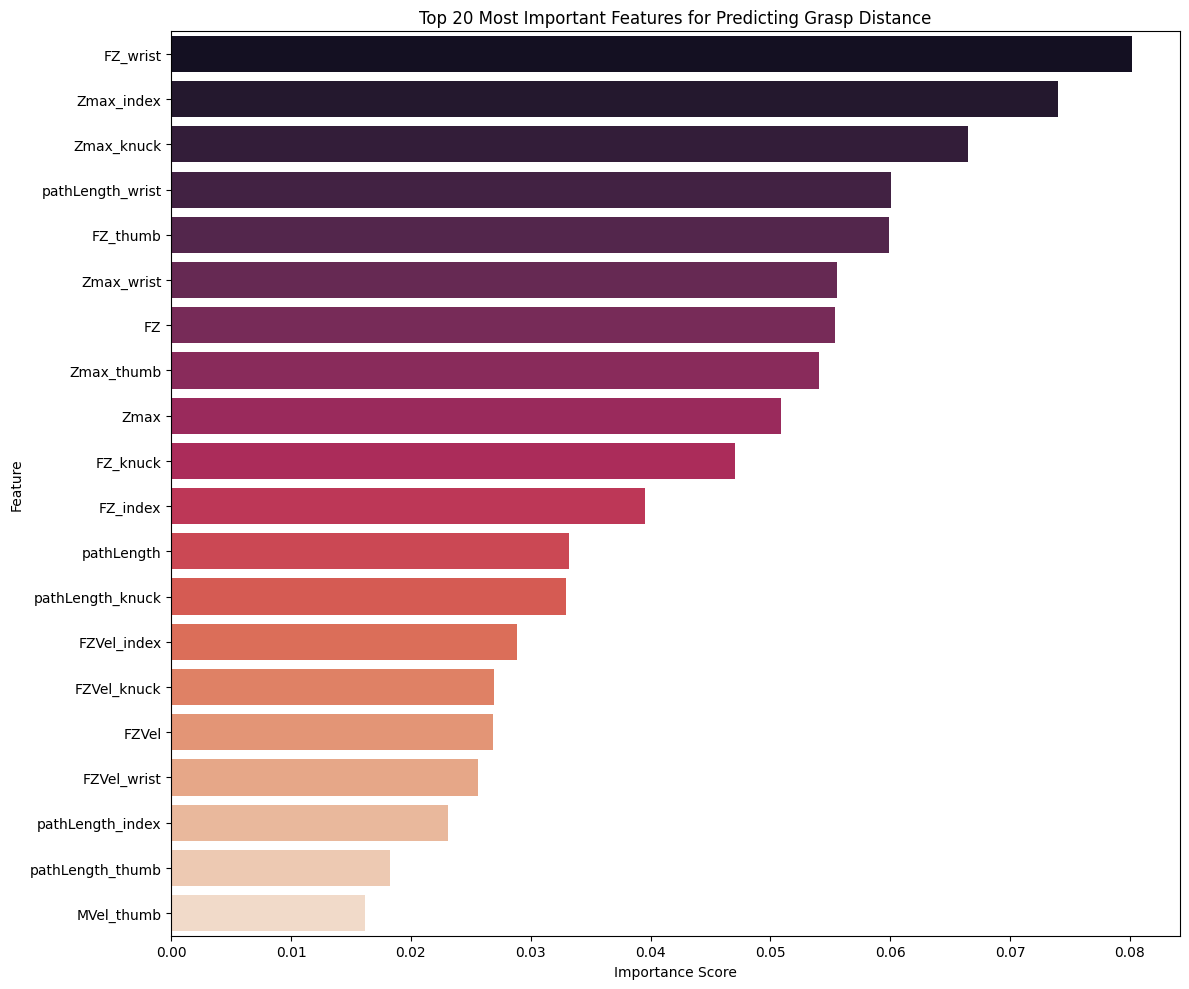


Top 10 most important features for predicting distance:
              feature  importance
80           FZ_wrist    0.080178
129        Zmax_index    0.074010
130        Zmax_knuck    0.066519
136  pathLength_wrist    0.060038
79           FZ_thumb    0.059872
132        Zmax_wrist    0.055573
11                 FZ    0.055382
131        Zmax_thumb    0.054088
26               Zmax    0.050894
78           FZ_knuck    0.047061


In [16]:
plt.figure(figsize=(12, 10))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20), palette='rocket')
plt.title('Top 20 Most Important Features for Predicting Grasp Distance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nTop 10 most important features for predicting distance:")
print(feature_importance_df.head(10))

Human grasping is not a single, uniform action but is composed of several classifiable strategies (e.g., "Ballistic Reach," "Corrective Grip").

The primary factor determining which strategy is chosen is the distance to the target object.

The most critical kinematic variables for planning a reach to a specific distance are the amplitude (Zmax) and force (FZ) of the movement in the forward direction.